In [1]:
import pandas as pd
import numpy as np 

In [2]:
df=pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
drop_cols=["PassengerId","Ticket","Name"]

In [4]:

# from config.config import drop_cols

def drop_column(df :pd.DataFrame ,cols:list[str])-> pd.DataFrame:
    """ 
        drop specific colmnus from dataframe
    
    """ 
    
    
    return df.drop(columns=cols)
    
    

In [5]:
df=drop_column(df, drop_cols)

In [6]:
# df.drop(["PassengerId","Ticket","Name"],axis=1, inplace=True)


In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Ckeck Data Type


In [8]:
dtypes=df.dtypes

n_unique=df.nunique()
n_unique

Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        248
Cabin       147
Embarked      3
dtype: int64

In [9]:
pd.DataFrame({"Dtypes: ": dtypes,"Num_unique: ":n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes:,int64,int64,object,float64,int64,int64,float64,object,object
Num_unique:,2,3,2,88,7,7,248,147,3


In [10]:
def get_check_dtype(df:pd.DataFrame)-> pd.DataFrame:
    return pd.DataFrame({"Dtypes: ": df.dtypes,"Num_unique: ":df.nunique()}).T

In [11]:
from ps import get_check_dtype
get_check_dtype(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes:,int64,int64,object,float64,int64,int64,float64,object,object
Num_unique:,2,3,2,88,7,7,248,147,3


In [12]:
cols=["Sex","Pclass","Survived","SibSp","Parch","Embarked"]
df[cols]=df[cols].astype("category")

pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,object,category


In [13]:
def change_cols(df: pd.DataFrame):
    cols = ["Sex", "Pclass", "Survived", "SibSp", "Parch", "Embarked"]
    
    df[cols] = df[cols].astype("category")
    
    return df
    

In [14]:
change_cols(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [15]:
null_values=df.isnull().sum()
null_values

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [16]:

type(null_values)

pandas.core.series.Series

In [17]:
ratio_val = null_values / df.shape[0]

pd.DataFrame({
    "nulls_sum": null_values,
    "Ratio": ratio_val
}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls_sum,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
Ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [18]:
df =df.dropna(subset=["Embarked"])

In [19]:
df=df.drop("Cabin",axis=1)

In [20]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [21]:
mean = df["Age"].mean()
print("Mean:", mean)

median = df["Age"].median()
print("Median:", median)

print("=" * 20)

df["Age"] = df["Age"].fillna(median)

Mean: 29.64209269662921
Median: 28.0


In [22]:
null_values = df.isnull().sum()

ratio_val = null_values / df.shape[0]

pd.DataFrame({
    "nulls_sum": null_values,
    "Ratio": ratio_val
}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
nulls_sum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [24]:
num_cols=df.select_dtypes("number").columns
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    
    
    IQR=Q3-Q1
    
    upper_fance=Q3+(1.5*IQR)
    lower_fance=Q1-(1.5*IQR)
    
    lower_outliers=df[df[col]<lower_fance][col].values
    print(lower_outliers)
    upper_outliers=df[df[col]>upper_fance][col].values
    print(upper_outliers)

[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65 

In [25]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


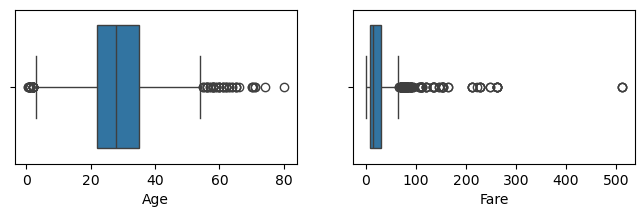

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols=df.select_dtypes("number").columns

plt.figure(figsize=(8,2))
for i, col in enumerate(num_cols):
    plt.subplot(1,2 ,i+1)
    sns.boxplot(df[ col],orient="h")



In [27]:
num_cols=df.select_dtypes("number").columns
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    
    
    IQR=Q3-Q1
    
    upper_fance=Q3+(1.5*IQR)
    lower_fance=Q1-(1.5*IQR)
    
    lower_outliers=df[df[col]<lower_fance][col].values
    print(lower_outliers)
    upper_outliers=df[df[col]>upper_fance][col].values
    print(upper_outliers)

[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65 

In [28]:
num_col = df.select_dtypes('number').columns
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5 *IQR
   
    lower_outliers = df[   df[col] <      lower_fence]    [col].values
    upper_outliers = df[   df[col] >      upper_fence]    [col].values
    
    
    df[col].replace(lower_outliers,lower_fance)
    df[col].replace(upper_outliers,upper_fance)
    

In [29]:
def plot_num_boxplot(df):
    
    num_cols=df.select_dtypes("number").columns

    plt.figure(figsize=(8,2))
    for i, col in enumerate(num_cols):
        plt.subplot(1,2 ,i+1)
        sns.boxplot(df[ col],orient="h")
        
    return plt.show()
    
    

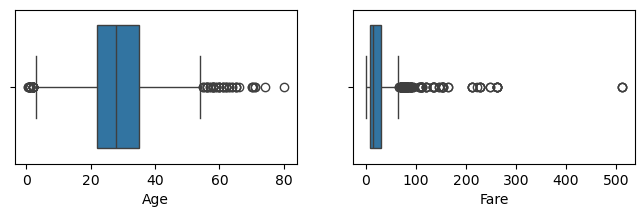

In [30]:
plot_num_boxplot(df)

In [31]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 889, dtype: bool

In [32]:
df.duplicated().sum()

np.int64(116)

In [33]:
df=df.drop_duplicates()

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
def remove_duplicated_records(df,subcols=None,keep_strategy="firsy"):
    return(df.drop_duplicates(subset=subcols,kepp=keep_strategy).reset_index(drop=True))

In [36]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = "first"):
    
    count=df.duplicated().sum()
    print(count)
    return (df.drop_duplicates(subset=subset_cols, keep=keep_strategy).reset_index(drop = True))
 

In [37]:
remove_duplicated_records(df).head()

0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


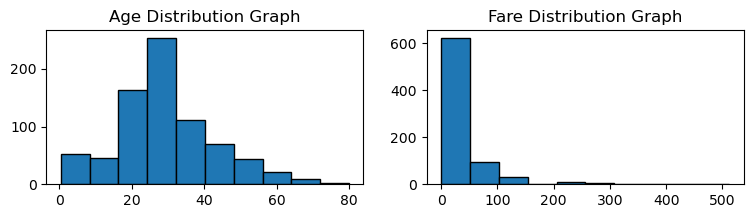

In [38]:
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} Distribution Graph")

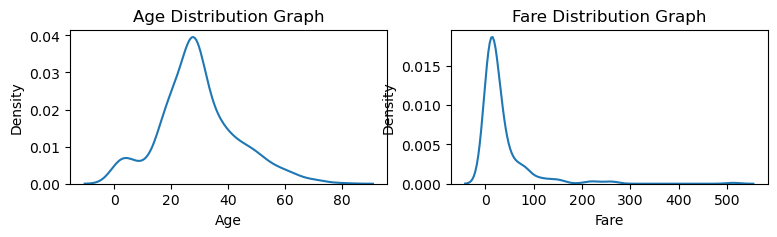

In [39]:
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Distribution Graph")

In [40]:
cat_cols=["Sex","Pclass","Survived","SibSp","Parch","Embarked"]
df[cat_cols]=df[cat_cols].astype("category")

C:\Users\G-A-M\AppData\Local\Temp\ipykernel_15568\4292467457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cat_cols]=df[cat_cols].astype("category")


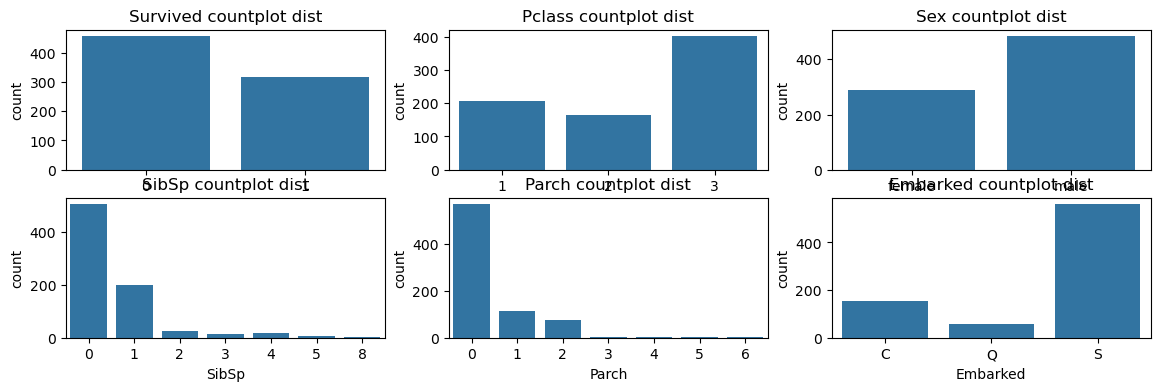

In [41]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} countplot dist")

In [42]:
unique=df[col].value_counts()
count=unique.values
count

array([560, 155,  58])

In [43]:
category=unique.index
category

CategoricalIndex(['S', 'C', 'Q'], categories=['C', 'Q', 'S'], ordered=False, dtype='category', name='Embarked')

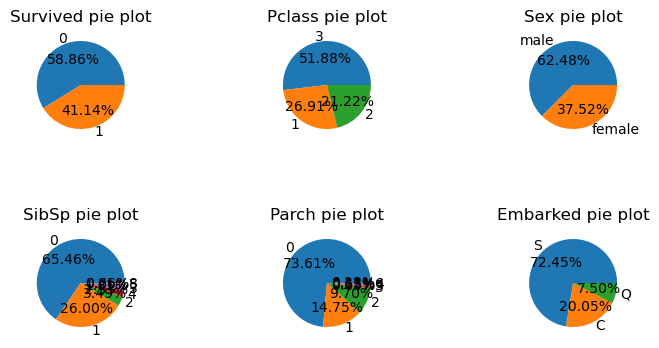

In [44]:
plt.figure(figsize=(9, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    
    counts = df[col].value_counts()
    
    plt.pie(counts.values, labels=counts.index, autopct='%1.2f%%')
    plt.title(f"{col} pie plot")

plt.subplots_adjust(hspace=0.8, wspace=0.2)
plt.show()

Text(0, 0.5, 'Fare')

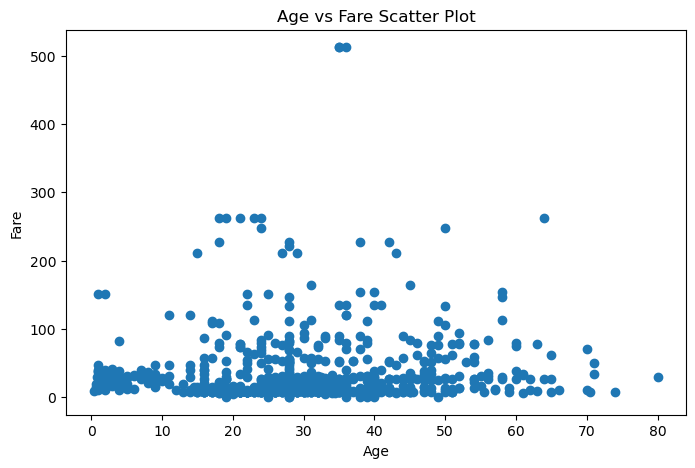

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Fare"])  
plt.title("Age vs Fare Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Fare")

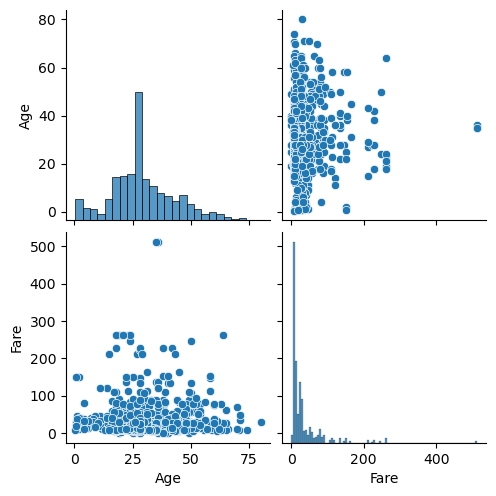

In [46]:
sns.pairplot(df)

In [47]:
corr_1=df.corr(numeric_only=True)
corr_1

,Age,Fare
Age,1.000000,0.089624
Fare,0.089624,1.000000


In [48]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [52]:
x= df.drop("Survived" , axis=1)
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
